# Importing libraries and dependancies 

In [14]:
# libraries
import pandas as pd # import pandas 
import numpy as np # import numpy 
import matplotlib.pyplot as plt # import matplotlib
import seaborn as sns # import seaborn  
%matplotlib inline
#import warnings
#warnings.filterwarnings('ignore')
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True'   


# For machine learning

#import sklearn # import sklearn
#from sklearn.model_selection import train_test_split # import train test split
#from sklearn.linear_model import LinearRegression # import linear regression
#from sklearn.metrics import mean_squared_error, r2_score # import metrics





In [15]:




pd.__version__


'2.3.1'

In [16]:
np.__version__

'2.3.1'

In [17]:
# load the dataset file onto   the working directory

#wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

In [18]:
# file path for the dataset
#file = '/Users/mnoneleligovuzela/Documents/Self-actualisation/Computation science/data science/ML learn/mlzoomcamp/mlzoom-main/02-regression/Application/car_fuel_efficiency.csv'

file ='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [19]:
# Load the data into a DataFrame for processing 
df = pd.read_csv(file)

In [20]:
# Data Structure: What are the rows and columns representing?
# How many features (columns) and observations (rows) are there?

In [21]:
#peek top five records
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [22]:
df['car_age'] = 2024 - df['model_year'] 

df.head()


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg,car_age
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729,21
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217,17
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341,6
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736,15
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369,15


In [23]:
# Number of records in df
df.shape

(9704, 12)

# EDA to check linear regresion assupmtion:
    # Linearity,Multicollinearity,and outliers 
    # NB: Homoskedacity,independence of errors,and normality of errors will be checked after fitting 


In [24]:
# Data Types: 
# What types of data are included (numerical, categorical, date/time, etc.)? 
# Understanding data types is crucial as it influences 
# how you analyze and visualize the data.
# Check data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
 11  car_age              9704 non-null   int64  
dtypes: float64(6), int64(3), object(3)
memory usage: 909.9+ KB


# Brief backgroung about the target variable : 
#(NB: THE INFO IS COPIED DIRECTLY FORM REFRENCES 1 AND 2 BELOW)
    
    #defination(fuel ) : Fuel economy is defined as the number of miles driven per gallon of gasoline consumed, commonly referred to as miles per gallon #(MPG). It is influenced by factors such as the size, shape, and weight of the vehicle, as well as driving conditions[1]. 

#NOTE: Fuel consumption is a more accurate measure of a vehicle's performance because it is a linear relationship while fuel economy leads to           #distortions in efficiency improvements.[2] Weight-specific efficiency (efficiency per unit weight) may be stated for freight, and passenger-specific # #efficiency (vehicle efficiency per passenger) for passenger vehicles[2].
# References : 
#1. https://www.sciencedirect.com/topics/engineering/fuel-economy#:~:text=In%20subject%20area:%20Engineering,Definition

#2. https://en.wikipedia.org/wiki/Fuel_efficiency
#3. https://engineering.mit.edu/engage/ask-an-engineer/whats-the-difference-between-fuel-efficiency-and-fuel-economy/

In [25]:
# segment df columns into categorical and numerical columns

cat_cols = df.select_dtypes(include=['object']).columns # Categorical columns
num_cols = df.select_dtypes(include=['number']).columns # Numerical columns


In [26]:
cat_cols

Index(['origin', 'fuel_type', 'drivetrain'], dtype='object')

In [27]:
num_cols

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'num_doors', 'fuel_efficiency_mpg',
       'car_age'],
      dtype='object')

In [28]:
# Check for missing values
#ALSO CORESPONDES TO Q4:

# Missin values in df
#Q4. Missing values
#How many columns in the dataset have missing values?
df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
car_age                  0
dtype: int64

In [29]:
# For numerical features
df[num_cols].isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
num_doors              502
fuel_efficiency_mpg      0
car_age                  0
dtype: int64

In [30]:
# For numerical features
(df[cat_cols].isna()==True).sum()

origin        0
fuel_type     0
drivetrain    0
dtype: int64

In [31]:
#UNI AND BIVARIATE ANALYSIS
    # The goal is to understand the distribution of the target variable and the relationships between the target variable and the features.
    # spot skewness, outliers, and other patterns that may affect the modeling process.
    # Univariate analysis of the target variable 'mpg'



In [32]:
# Summary statistics of numerical columns
df.describe()


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg,car_age
count,9704.000000,9222.000000,8996.000000,9704.000000,8774.000000,9704.000000,9202.000000,9704.000000,9704.000000
mean,199.708368,3.962481,149.657292,3001.280993,15.021928,2011.484027,-0.006412,14.985243,12.515973
std,49.455319,1.999323,29.879555,497.894860,2.510339,6.659808,1.048162,2.556468,6.659808
min,10.000000,0.000000,37.000000,952.681761,6.000000,2000.000000,-4.000000,6.200971,1.000000
25%,170.000000,3.000000,130.000000,2666.248985,13.300000,2006.000000,-1.000000,13.267459,7.000000
50%,200.000000,4.000000,149.000000,2993.226296,15.000000,2012.000000,0.000000,15.006037,12.000000
75%,230.000000,5.000000,170.000000,3334.957039,16.700000,2017.000000,1.000000,16.707965,18.000000
max,380.000000,13.000000,271.000000,4739.077089,24.300000,2023.000000,4.000000,25.967222,24.000000


In [33]:
# understand the distribution of the target variable and the relationships between the target variable and the features.
    # spot skewness, outliers, and other patterns that may affect the modeling process.
    # Univariate analysis of the target variable 'mpg'

In [34]:
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg', 'car_age'],
      dtype='object')

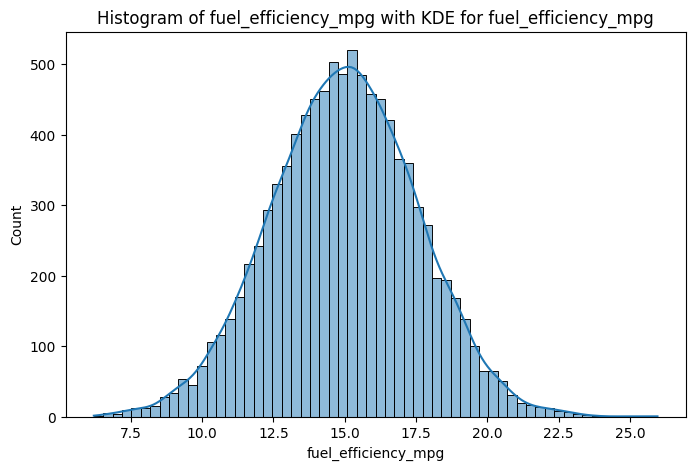

In [35]:
# Distribution of target feature

plt.figure(figsize=(8, 5))
sns.histplot(df['fuel_efficiency_mpg'], bins=60, kde=True)  # kde=True adds smooth line
plt.title(f"Histogram of fuel_efficiency_mpg with KDE for fuel_efficiency_mpg")
plt.show()


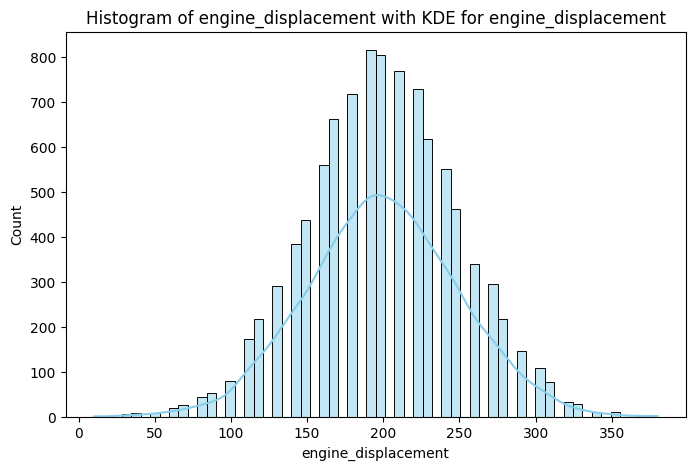

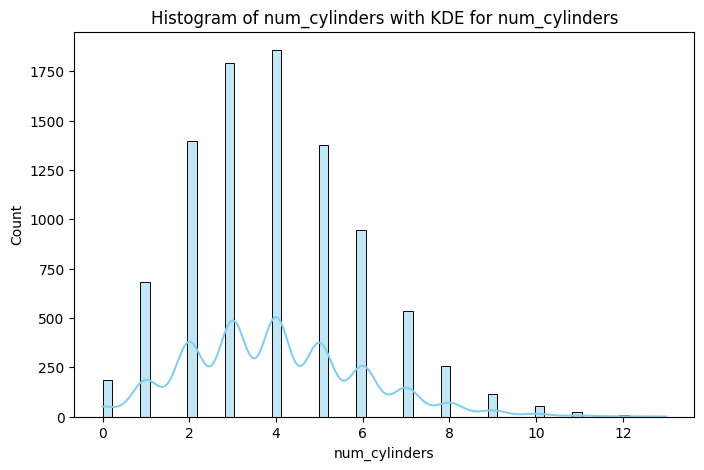

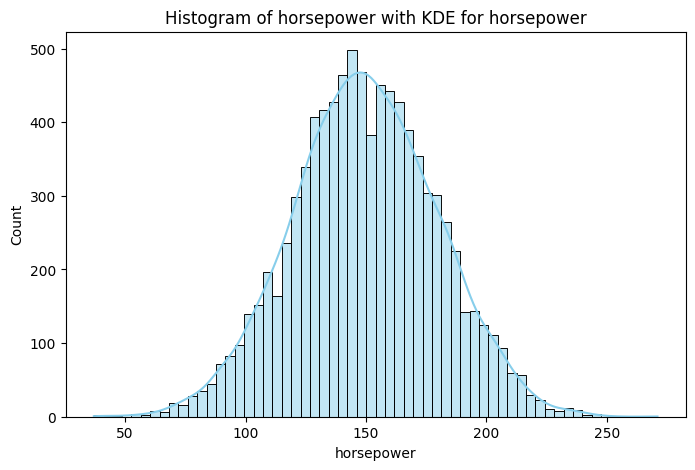

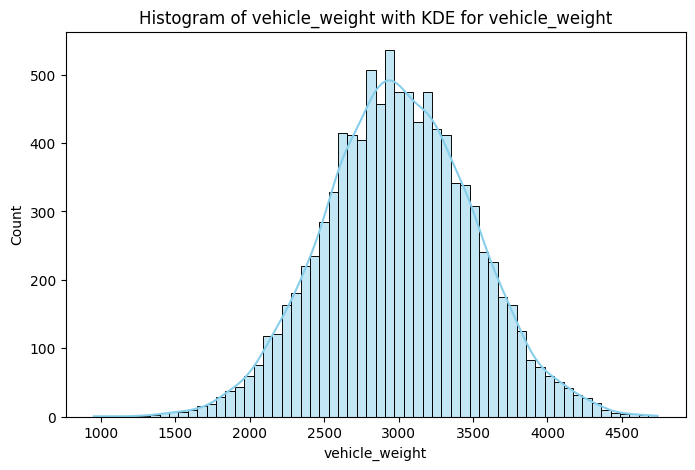

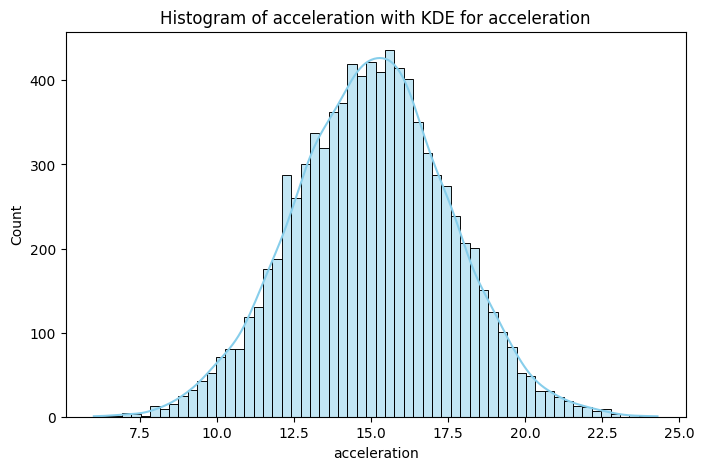

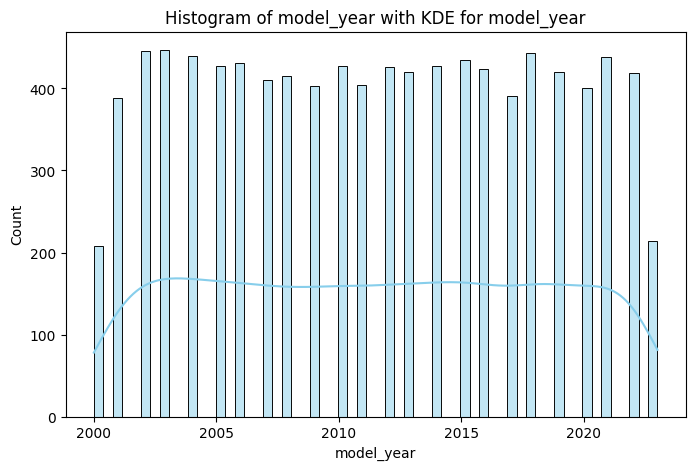

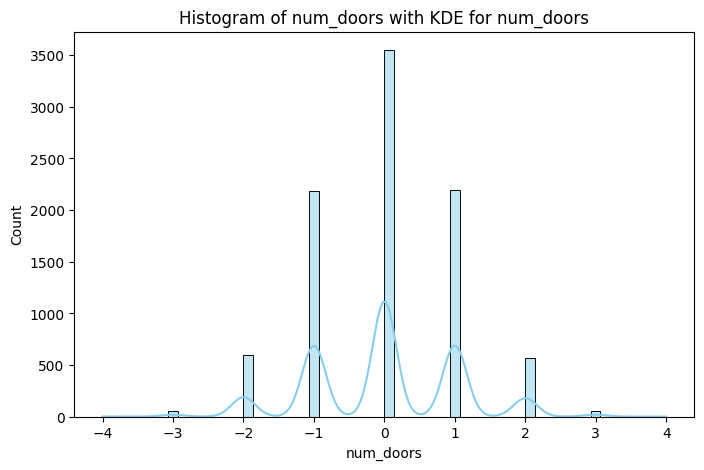

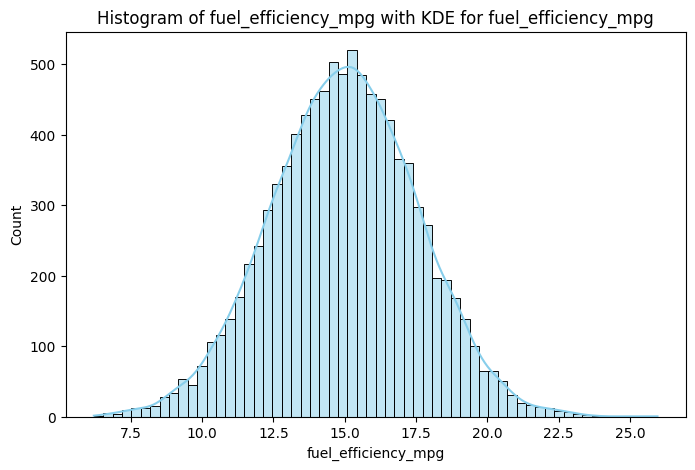

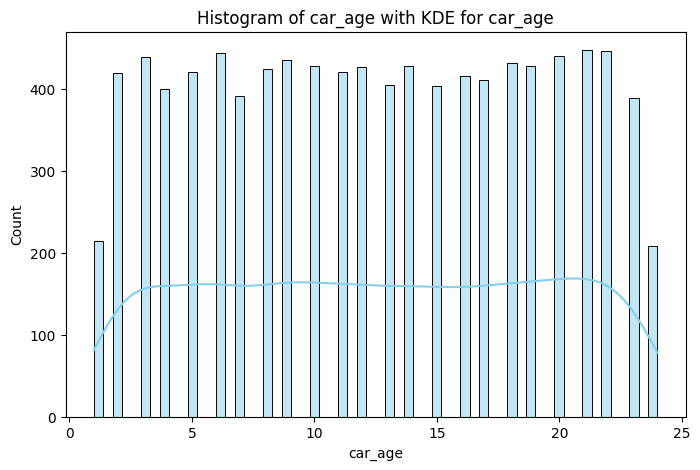

In [36]:
# Distribution of numerical features


for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), bins=60, kde=True,color="skyblue")  # kde=True adds smooth line
    plt.title(f"Histogram of {col} with KDE for {col}")
plt.show()


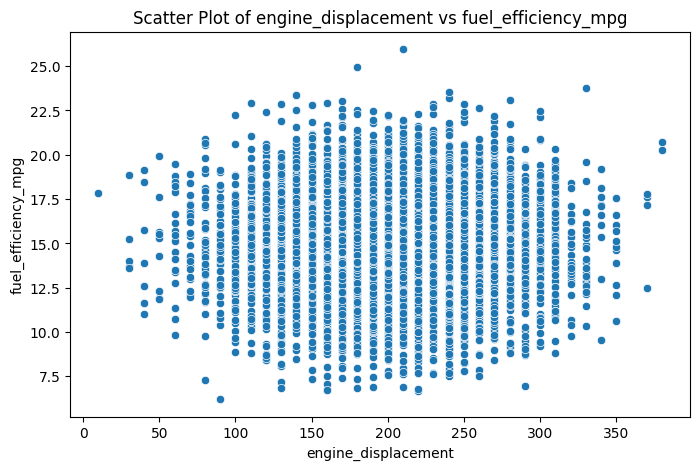

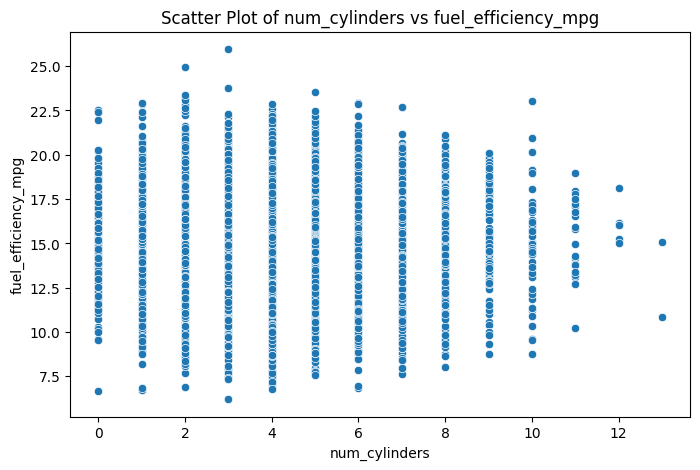

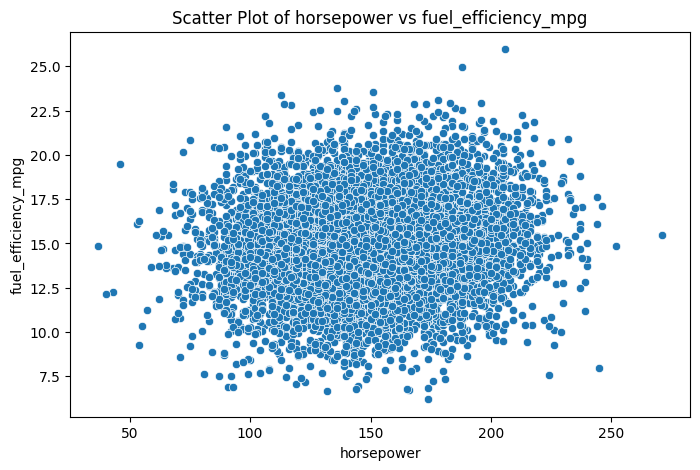

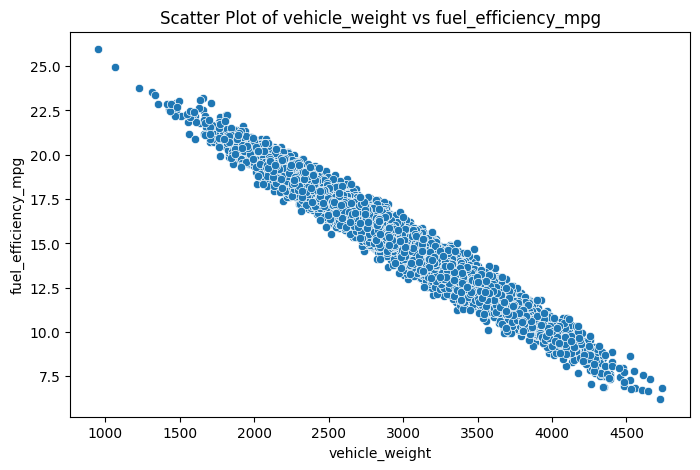

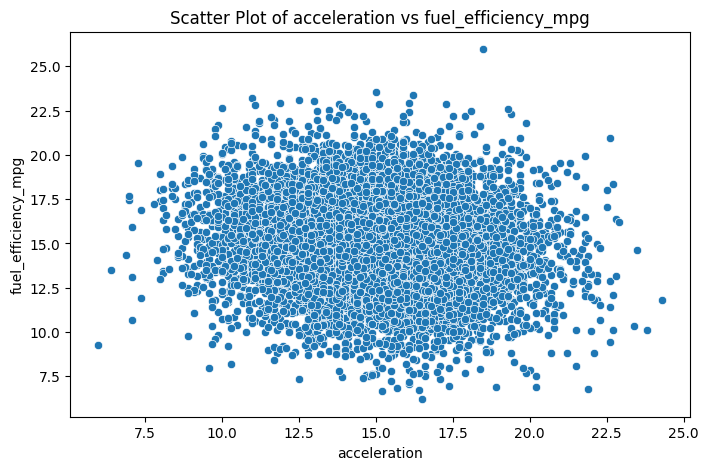

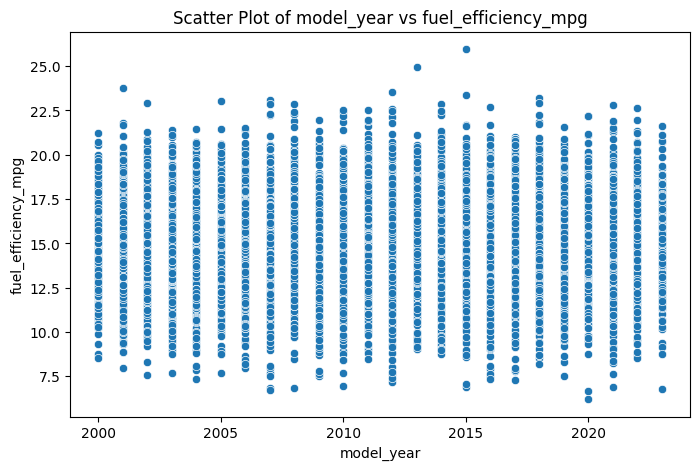

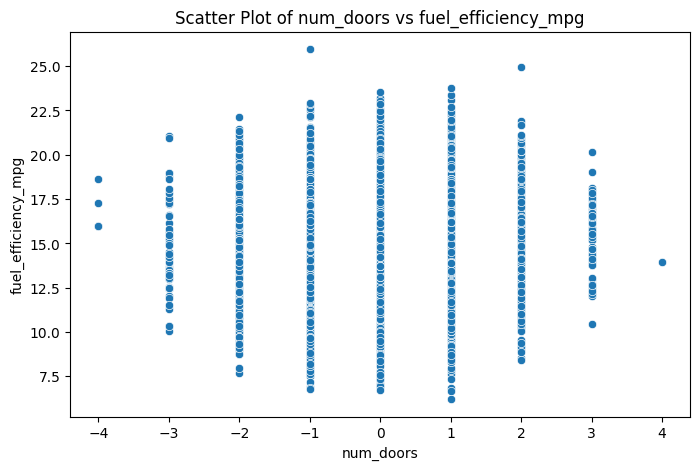

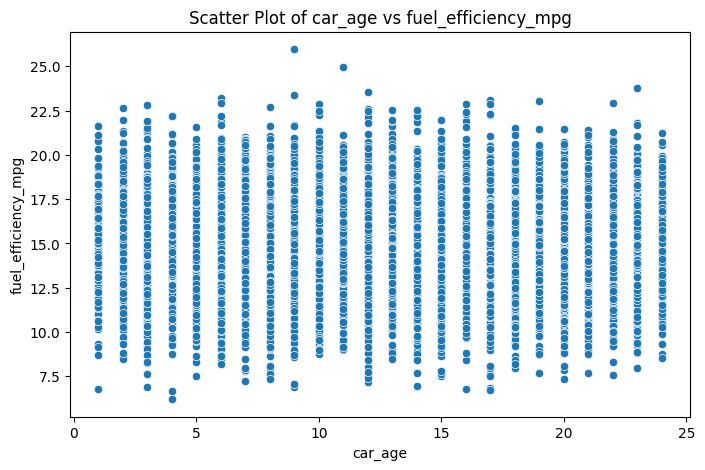

In [37]:
# scatter plots of numerical features against the target variable fuel_efficiency_mpg
for col in num_cols:
    if col != 'fuel_efficiency_mpg':
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x=df[col], y=(df['fuel_efficiency_mpg']))
        plt.title(f'Scatter Plot of {col} vs fuel_efficiency_mpg')
        plt.xlabel(col)
        plt.ylabel('fuel_efficiency_mpg')
        plt.show()

In [38]:
# Noting the relationship between 'engine_displacement' and 'num_cylinders' in Otto/Diesel engines

# 'engine_displacement' = pi*(Bore/2)^2*stroke*'num_cylinders' 
# Or  'num_cylinders' = [(pi*(Bore/2)^2*stroke)]^-1*'engine_displacement'

# Refs:
# 1.https://www.idc-online.com/technical_references/pdfs/mechanical_engineering/Engine_displacement.pdf

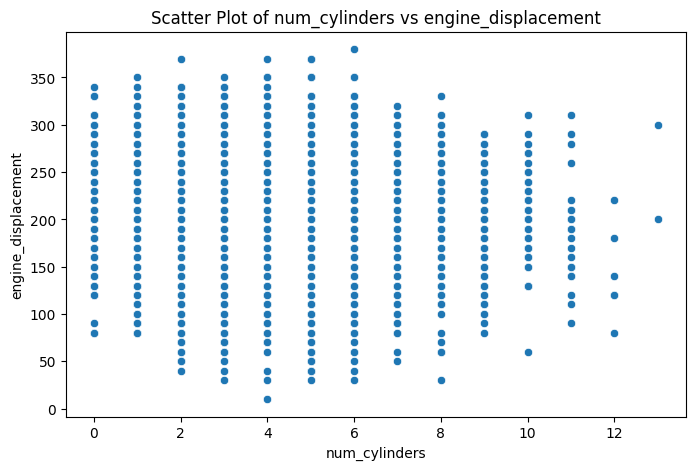

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=df['num_cylinders'], y=df['engine_displacement'])
plt.title(f'Scatter Plot of num_cylinders vs engine_displacement')
plt.xlabel('num_cylinders')
plt.ylabel('engine_displacement')
plt.show()

# This plot suggest that there is not association between the variables

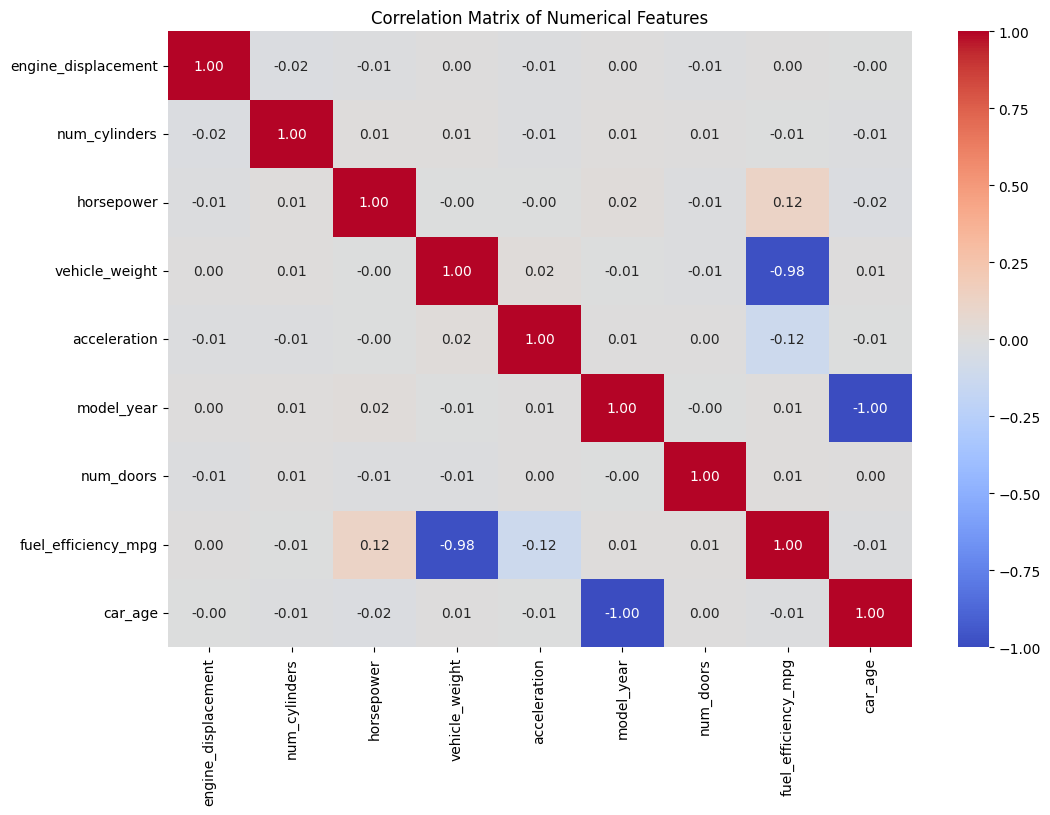

In [40]:
# heatmap to visualize correlations
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')       
plt.show()

# Notes and concluion on EDA on num_cols
## 

In [41]:
# Frequency counts of categorical columns
for col in cat_cols:
    print(df[col].value_counts())   

origin
Europe    3254
Asia      3247
USA       3203
Name: count, dtype: int64
fuel_type
Gasoline    4898
Diesel      4806
Name: count, dtype: int64
drivetrain
All-wheel drive      4876
Front-wheel drive    4828
Name: count, dtype: int64


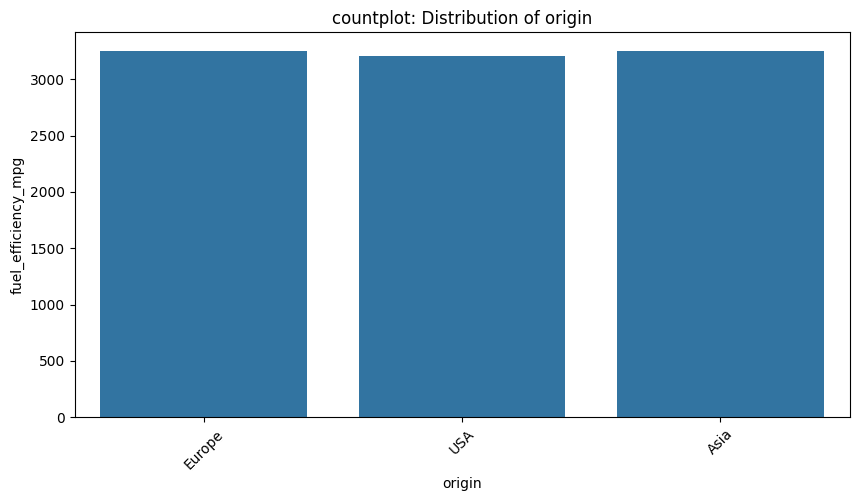

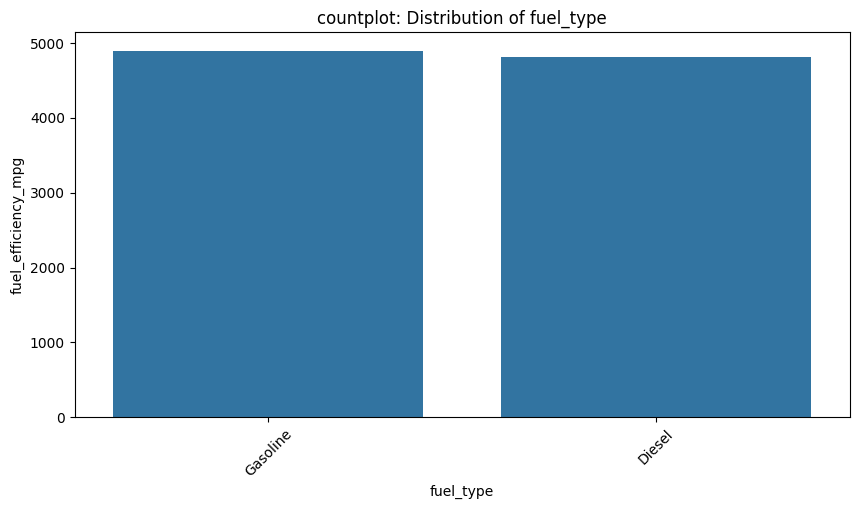

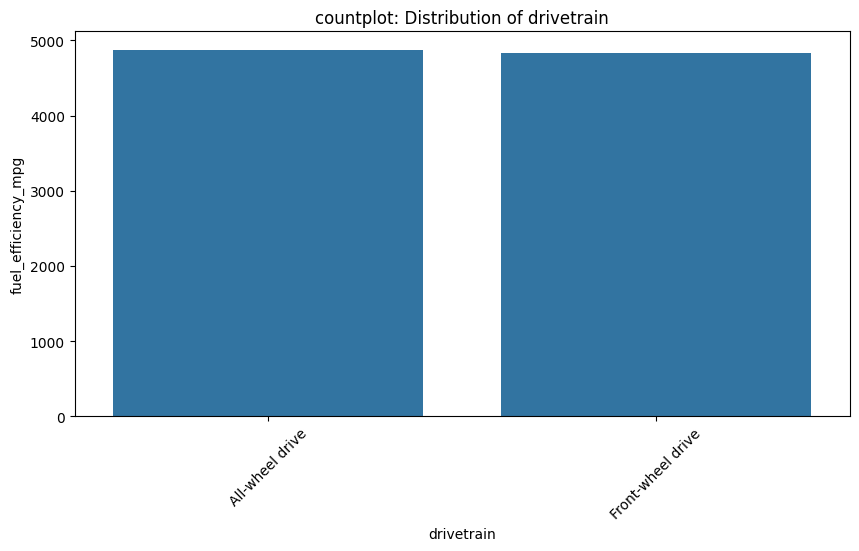

In [42]:
# For the categorical variables frequency we will use count plots to see the feature  distribution
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=df[col])
    plt.title(f'countplot: Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('fuel_efficiency_mpg')
    plt.xticks(rotation=45)
    plt.show()




In [43]:
#Q3. Fuel types
#How many fuel types are presented in the dataset?
df['fuel_type'].value_counts()

fuel_type
Gasoline    4898
Diesel      4806
Name: count, dtype: int64

In [44]:
# df columns names

df.columns



Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg', 'car_age'],
      dtype='object')

In [45]:
#Q5. Max fuel efficiency
#What's the maximum fuel efficiency of cars from Asia?

df[['origin','fuel_efficiency_mpg']][df['origin'] =='Asia'].max()

origin                      Asia
fuel_efficiency_mpg    23.759123
dtype: object

#Question 6. Median value of horsepower (1 point)
#Q6. Median value of horsepower
    # Find the median value of horsepower column in the dataset.
    # Next, calculate the most frequent value of the same horsepower column.
    # Use fillna method to fill the missing values in horsepower column with the most frequent value from the previous step.
    # Now, calculate the median value of horsepower once again.
        # Has it changed?
        # Yes, it increased
        # Yes, it decreased
        # No


In [46]:
 # Find the median value of horsepower column in the dataset.
 df['horsepower'].median(numeric_only=True)

np.float64(149.0)

In [47]:
# Next, calculate the most frequent value of the same horsepower column.
df['horsepower'].mode()

0    152.0
Name: horsepower, dtype: float64

In [48]:
# Use fillna method to fill the missing values in horsepower column with the most frequent value from the previous step.
df['horsepower'].fillna(df['horsepower'].mode()[0],inplace =True)


/tmp/ipykernel_10297/4252760884.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mode()[0],inplace =True)


In [49]:
 # Now, calculate the median value of horsepower once again.
 # And determine if :
        # Has it changed?
        # Yes, it increased
        # Yes, it decreased
        # No
 
df['horsepower'].median(numeric_only=True)

np.float64(152.0)

# Q7. Sum of weights

#Select all the cars from Asia
#Select only columns vehicle_weight and model_year
#Select the first 7 values
#Get the underlying NumPy array. Let's call it X.
#Compute matrix-matrix multiplication between the transpose of X and X. To get the transpose, use X.T. Let's call the result XTX.
#Invert XTX.
#Create an array y with values [1100, 1300, 800, 900, 1000, 1100, 1200].
#Multiply the inverse of XTX with the transpose of X, and then multiply the result by y. Call the result w.
#What's the sum of all the elements of the result?

In [50]:
#Select all the cars from Asia
df_asia = df[df['origin']=='Asia']
df_asia.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg,car_age
8,250,1.0,174.0,2714.219310,10.3,2016,Asia,Diesel,Front-wheel drive,-1.0,16.823554,8
12,320,5.0,145.0,2783.868974,15.1,2010,Asia,Diesel,All-wheel drive,1.0,16.175820,14
14,200,6.0,160.0,3582.687368,14.9,2007,Asia,Diesel,All-wheel drive,0.0,11.871091,17
20,150,3.0,197.0,2231.808142,18.7,2011,Asia,Gasoline,Front-wheel drive,1.0,18.889083,13
21,160,4.0,133.0,2659.431451,NaN,2016,Asia,Gasoline,Front-wheel drive,-1.0,16.077730,8


In [51]:
#Select only columns vehicle_weight and model_year

df_asia = df_asia[['vehicle_weight','model_year']] 
df_asia.head(7)

,vehicle_weight,model_year
8,2714.219310,2016
12,2783.868974,2010
14,3582.687368,2007
20,2231.808142,2011
21,2659.431451,2016
34,2844.227534,2014
38,3761.994038,2019


In [52]:
#Select the first 7 values
df_asia.iloc[:7]

,vehicle_weight,model_year
8,2714.219310,2016
12,2783.868974,2010
14,3582.687368,2007
20,2231.808142,2011
21,2659.431451,2016
34,2844.227534,2014
38,3761.994038,2019


In [53]:
#Get the underlying NumPy array. Let's call it X.


import numpy as np # import numpy

X = np.array(df_asia[['vehicle_weight','model_year']].iloc[:7])
X.ndim
# Compute matrix-matrix multiplication between the transpose of X and X.
# To get the transpose, use X.T. Let's call the result XTX.

XTX  = np.dot(X.T,X)

In [54]:
# Due to the requirement of the next step-to compute the inverse of XTX. 
# Our numpy matrix must be square.
# Hence the function to check if the matrix is square below.
def is_square_numpy_matrix(matrix):
    """Takes a numpy matrix as input ,checks if it is square and returns a True or False value"""
    if not isinstance(matrix, np.ndarray): 
        raise TypeError("Input must be a NumPy array.")
    
    if matrix.ndim != 2:  # Ensure it's a 2D matrix
        return False
        
    rows, cols = matrix.shape
    return rows == cols


In [55]:
is_square_numpy_matrix(XTX)

True

In [56]:
#Compute the inverse of XTX.

XTX_inv = np.linalg.inv(XTX)

#Create an array y with values [1100, 1300, 800, 900, 1000, 1100, 1200].

y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])
#Multiply the inverse of XTX with the transpose of X, and then multiply the result by y. Call the result w.
#What's the sum of all the elements of the result?

w = np.dot(np.dot(XTX_inv,X.T),y)

In [57]:
w.sum()

np.float64(0.5187709081074016)

In [58]:

for col in df.columns:
    print(col)
    print(df[col].unique()[:df[col].nunique()])
    print(df[col].nunique())

engine_displacement
[170 130 220 210 190 240 150 250 230 320 200 160 180 260 120 280  40  80
 110 380 270 140 290 340 310 100  90 330 300 350  70  60 370  50  10  30]
36
num_cylinders
[ 3.  5. nan  4.  1.  7.  6.  2.  8.  0.  9. 12. 10. 11.]
14
horsepower
[159.  97.  78. 152. 140. 127. 239. 174. 123. 100. 145. 193. 160. 179.
 180. 132. 110. 126. 197. 133. 144. 156. 157. 206. 154. 153. 136. 168.
 149. 143. 158. 176. 108. 125. 142. 139. 170. 135. 202.  99. 148. 151.
 155. 146. 199. 128. 103. 182. 141. 113. 109. 196. 111. 118. 222. 122.
 194. 166. 101.  72. 232. 172. 165. 177. 190. 129. 184. 147. 137. 163.
 162. 186. 104. 120. 200. 189. 167. 164. 191. 195.  96. 181.  71. 130.
 150. 192. 217. 112. 220. 185.  83. 124. 161. 169.  98. 117. 134.  80.
  92. 115. 121. 214.  94.  90. 210. 138. 198. 175. 183. 187. 173.  95.
 131. 106. 204.  93. 114. 178. 207. 171. 188. 230.  87. 227. 119. 105.
 102.  73. 208. 116.  79.  91. 209.  68. 237.  89.  82.  77. 213.  59.
 216. 201.  66.  88.  53. 205. 223

In [59]:
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg', 'car_age'],
      dtype='object')

In [60]:
# num_doors has out of range entries .Suggesting that these are used to handle missing values.
# Therefore, i will mark them are missing value using NaN variable from numpy
#num_doors=[ 0.  2. -1.  1. nan -2. -3.  3. -4.]
for i in range(len(df)):
    if df.loc[i, 'num_doors'] <= 0:   # check if 0 or negative
        df.loc[i, 'num_doors'] = np.nan


In [61]:
df['num_doors'].isna().sum()



np.int64(6890)

In [62]:
for col in df.columns:
    n_miss =df[col].isna().sum()
    perc=(n_miss /df[col].shape[0])*100
    print('> %s, Missing: %d (%.1f%%)' % (col, n_miss, perc))
    #print('The  %s feature has %.2f\% of data missing'%(col,per_missing))

> engine_displacement, Missing: 0 (0.0%)
> num_cylinders, Missing: 482 (5.0%)
> horsepower, Missing: 0 (0.0%)
> vehicle_weight, Missing: 0 (0.0%)
> acceleration, Missing: 930 (9.6%)
> model_year, Missing: 0 (0.0%)
> origin, Missing: 0 (0.0%)
> fuel_type, Missing: 0 (0.0%)
> drivetrain, Missing: 0 (0.0%)
> num_doors, Missing: 6890 (71.0%)
> fuel_efficiency_mpg, Missing: 0 (0.0%)
> car_age, Missing: 0 (0.0%)


In [63]:
# We have a choice of using stats-imputation with [mean,median.mode,conctant value] on each columns or advanced techniques
# Now how do we decide?



In [64]:
# delete num_doors column as it has many missing values and it is categorical with many levels
df= df.drop('num_doors', axis=1)

# Set up the validation framework


In [65]:
n = len(df)
n_val = int(n*0.2)
n_test =int(n*0.2)
n_train = n-n_val-n_test
#check if we sliced correctly
n == n_train+n_val+n_test

True

In [66]:

df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

#check

len(df) == len(df_train)+len(df_val)+len(df_test)
df.shape[0] == df_train.shape[0]+ df_val.shape[0]+df_test.shape[0]


True

In [67]:

# Shuffle index

idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

In [68]:
idx

array([ 483, 7506, 8795, ..., 5390,  860, 7270], shape=(9704,))

In [69]:
idx_train = idx[:n_train]
idx_val = idx[n_train:n_train+n_val]
idx_test = idx[n_train+n_val:]

df_train = df.iloc[idx_train]

df_val = df.iloc[idx_val]

df_test = df.iloc[idx_test]

#len(df) == len(df_train)+len(df_val)+len(df_test)
df.shape[0] == df_train.shape[0]+ df_val.shape[0]+df_test.shape[0]

True

In [70]:
len(idx) ==len(idx_train) +len(idx_val)+len(idx_test)

True

In [71]:
# Reset index for all dataframes
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)    

# Target variable
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values



In [72]:

#  Remove the target variable from the feature set
df_train = df_train.drop('fuel_efficiency_mpg', axis=1)
df_val = df_val.drop('fuel_efficiency_mpg', axis=1)
df_test = df_test.drop('fuel_efficiency_mpg', axis=1)

# Linear regression



In [73]:
for i in range(3):
    print('row ',i+1,end = " :" )
    print(df_train.iloc[i])
    print()

row  1 :engine_displacement                220
num_cylinders                      3.0
horsepower                       144.0
vehicle_weight             2535.887591
acceleration                      18.7
model_year                        2009
origin                             USA
fuel_type                     Gasoline
drivetrain             All-wheel drive
car_age                             15
Name: 0, dtype: object

row  2 :engine_displacement                  160
num_cylinders                        2.0
horsepower                         141.0
vehicle_weight               2741.170484
acceleration                        14.3
model_year                          2019
origin                              Asia
fuel_type                         Diesel
drivetrain             Front-wheel drive
car_age                                5
Name: 1, dtype: object

row  3 :engine_displacement                  230
num_cylinders                        3.0
horsepower                         155.0
vehic

In [74]:
def lr(xi):

    '''takes a 1D numpy array as input and returns the predicted value using linear regression coefficients w'''

    n = len(xi)
    pred = w0

    for i in range(n):
        pred += w[i] * xi[i]
    return pred


# Training the linear regression model

In [75]:
def train_linear_regression(X,y):
    '''Takes a 2D numpy array X and 1D numpy array y as input and returns the linear regression coefficients w and intercept w0'''
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X))  # Add intercept term
    XTX = np.dot(X.T, X)
    XTX_inv = np.linalg.inv(XTX)
    w = np.dot(np.dot(XTX_inv, X.T), y)
    w0 = w[0]  # Intercept
    w = w[1:]  # Coefficients
    return w, w0



# baseline model


In [76]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year']

df_train[base].isna().sum() 



engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [77]:
X_train = df_train[base].values

w,w0 = (train_linear_regression(X_train,y_train))

w,w0

(array([ 0.00011996,  0.01029946, -0.00501022, -0.00023572]),
 np.float64(28.926702378544658))

In [78]:
y_pred = w0 + np.dot(X_train, w)

/tmp/ipykernel_10297/3772263896.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


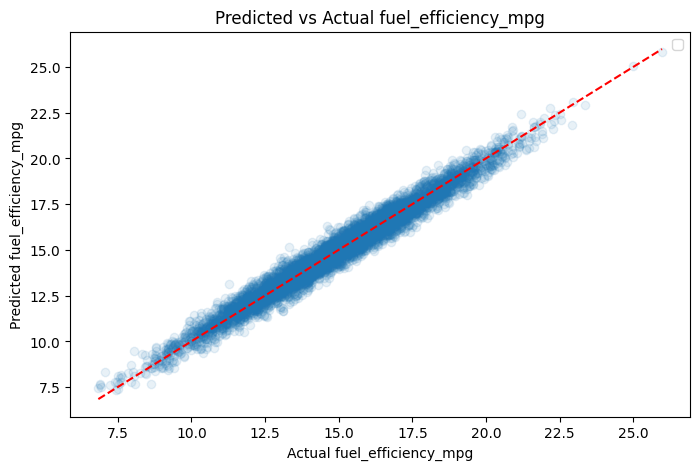

In [79]:
# Plot y_pred against y_train
plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_pred, alpha=0.1)     
plt.xlabel('Actual fuel_efficiency_mpg')    
plt.ylabel('Predicted fuel_efficiency_mpg')
plt.title('Predicted vs Actual fuel_efficiency_mpg')
plt.legend()
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')  # Diagonal line
plt.show()


<Axes: ylabel='Count'>

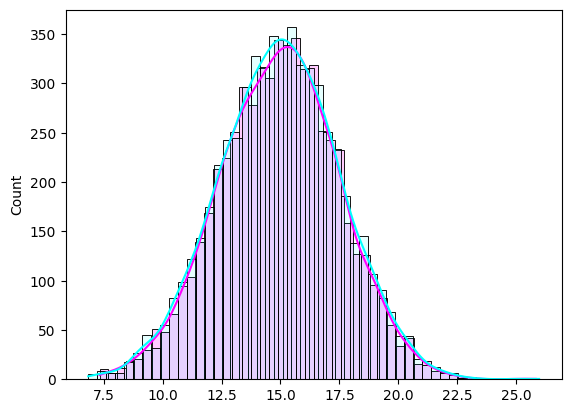

In [80]:
sns.histplot(y_pred, bins=50, kde=True,color ='magenta',alpha = 0.2)  # kde=True adds smooth line
sns.histplot(y_train, bins=50, kde=True,color ='cyan',alpha =0.1)  # kde=True adds smooth line


# RMSE

In [81]:
def rmse(y_pred,y_actual):
    '''Takes two 1d np.arrays as input and returns the root mean squared error between them'''
    return np.sqrt(((y_pred - y_actual) ** 2).mean())

In [82]:
rmse(y_pred,y_train)

np.float64(0.46245878083993486)

# RMSE on validation data

model validation

In [83]:
X_val = df_val[base].values
w,w0 =train_linear_regression(X_val,y_val)
y_pred_val = w0 + np.dot(X_val, w)
y_pred_val

# model validation
rmse(y_pred_val,y_val)


np.float64(0.46323493845782787)

# Feature engineering

In [84]:
df_train.isna().sum()

engine_displacement      0
num_cylinders          307
horsepower               0
vehicle_weight           0
acceleration           551
model_year               0
origin                   0
fuel_type                0
drivetrain               0
car_age                  0
dtype: int64

In [85]:
def prepare_X(df,base,new_features_list=None,fill_strategy='median'):

    """Prepares the feature matrix X from a dataframe.
    Parameters
    ________________
    df: type pd.DataFrame as an input dataset
    base: A list of standard/base features choosen for training.
    new_features: an optional list of feature(s) that are added incrementaly
    fill_strategy: str,optional ,with options('median','mean',or 'mode'),default value is median. To fill missing values.  
    Returns
    --------
    X: np.array, feature matrix
    """

    #create a copy of the dataframe to avoid modifying the original one
    df = df.copy()
    # create a new column : age of the car
    
    # base features
    final_features  = base.copy()

    # update the base features list to include the new features
    if new_features_list:

        for i in range(len(new_features_list)):

            if new_features_list[i] not in df.columns:

                raise ValueError(f"Feature '{new_features_list[i] }' not found in DataFrame")
            if new_features_list[i] not in final_features:
                base.append(new_features_list[i])
    # Handle missing values: for each check feature if the new feature has missing values 
    for i in range(len(final_features)):

        if df[final_features[i]].isna().sum() > 0: #fill missing values

            if fill_strategy=='median':

                fillvalue = df[final_features[i]].median()

            elif fill_strategy=='mean':

                fillvalue = df[final_features[i]].mean()

            elif   fill_strategy=='mode':

                fillvalue = df[final_features[i]].mode()[0]
            else:
                raise ValueError("The fillstrategy MUST BE 'median','mean',or 'mode ' ONLY")

            df[final_features[i]].fillna(fillvalue, inplace=True)

    df_num = df[final_features]

    X = df_num.values
    
    return X

In [86]:
def apply_model(X,target):
    """Applies the trained linear regression model to the given dataframe and returns the RMSE on the validation set."""
    w,w0 =train_linear_regression(X,target)
    y_pred = w0 + np.dot(X, w)

    # model validation
    rmse_score = rmse(y_pred,target)
    return rmse_score 


In [87]:
base

['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [88]:

['acceleration','num_cylinders']
# train the model on the training set
X = prepare_X(df_train,base,[])
apply_model(X,y_train)

np.float64(0.46245878083993486)

# Categorical variables


In [89]:
df_train.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'car_age'],
      dtype='object')

In [90]:
df['origin'].value_counts()

origin
Europe    3254
Asia      3247
USA       3203
Name: count, dtype: int64

In [91]:
def category_items(cat_cols):
    """ takes a list of categorical columns as input and returns a dictionary with unique values for each column
    
    Parameters
    ________________
    
    cat_cols: A list of categorical attributes(df.dtypes=='object' ).
    Returns
    --------
    cats: A dictionary with unique values for each column
    """
    cats = {}
    for col in cat_cols:
        cats[col] = list(df_train[col].value_counts().index)
    return cats

# Using this function to get unique values for categorical columns in df_train
cats = category_items(cat_cols)

for key,value in cats.items():
    i = 0
    #print(f"{key} : {value}")
    for v in value:
        
        print(f"{i+1}-{v}")
        i += 1
    print()

1-Asia
2-Europe
3-USA

1-Gasoline
2-Diesel

1-All-wheel drive
2-Front-wheel drive



In [92]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year']

In [93]:
def prepare_X(df,base,new_features_list=None,fill_strategy='median',encode_list=None):

    """Prepares the feature matrix X from a dataframe.
    Parameters
    ________________
    df: type pd.DataFrame as an input dataset
    base: A list of standard/base features choosen for training.
    new_features: an optional list of feature(s) that are added incrementaly
    fill_strategy: str,optional ,with options('median','mean',or 'mode'),default value is median. To fill missing values.  
    encode_list: list of categorical features 
    Returns
    --------
    X: np.array, feature matrix
    """

    #create a copy of the dataframe to avoid modifying the original one
    df = df.copy()
    # base features
    final_features  = base.copy()
# encode categorical features
    if encode_list is not None and len(encode_list) != 0:
        for col in encode_list:
            if col not in df.columns:
                raise ValueError(f"Feature '{col}' not found in DataFrame")
            else:
                for val in df[col].unique():
                    new_col_name = f'{col}_{val}'
                    df[new_col_name] = (df[col] == val).astype(int)
                df = df.drop(columns=[col])

    # update the base features list to include the new features
    if new_features_list:

        for i in range(len(new_features_list)):

            if new_features_list[i] not in df.columns:

                raise ValueError(f"Feature '{new_features_list[i] }' not found in DataFrame")
            
            if new_features_list[i] not in final_features:
                
                base.append(new_features_list[i])
    # Handle missing values: for each check feature if the new feature has missing values 
    for i in range(len(final_features)):

        if df[final_features[i]].isna().sum() > 0: #fill missing values

            if fill_strategy=='median':

                fillvalue = df[final_features[i]].median()

            elif fill_strategy=='mean':

                fillvalue = df[final_features[i]].mean()

            elif   fill_strategy=='mode':

                fillvalue = df[final_features[i]].mode()[0]
            else:
                raise ValueError("The fillstrategy MUST BE 'median','mean',or 'mode ' ONLY")

            df[final_features[i]].fillna(fillvalue, inplace=True)

    df_num = df[final_features]
    df_num.fillna(0)
    X = df_num.values
    
    return X

In [94]:
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'fuel_efficiency_mpg', 'car_age'],
      dtype='object')

In [95]:
# Different combinations of base features 
#base = ['engine_displacement','horsepower','vehicle_weight','car_age']
base = ['engine_displacement','horsepower','model_year','vehicle_weight','acceleration','num_cylinders','car_age']
#base = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year']
base


['engine_displacement',
 'horsepower',
 'model_year',
 'vehicle_weight',
 'acceleration',
 'num_cylinders',
 'car_age']

In [96]:
cat_cols

Index(['origin', 'fuel_type', 'drivetrain'], dtype='object')

In [97]:

base

['engine_displacement',
 'horsepower',
 'model_year',
 'vehicle_weight',
 'acceleration',
 'num_cylinders',
 'car_age']

In [98]:
X = prepare_X(df_train,base,[],encode_list=cat_cols)
apply_model(X,y_train)

/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[final_features[i]].fillna(fillvalue, inplace=True)
/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

np.float64(9.912161727269451)

In [99]:
w,w0 = train_linear_regression(X,y_train)
w,w0

(array([ 2.81180670e-05,  1.03256068e-02,  3.18470285e-01, -5.00438990e-03,
        -1.00607559e-01, -3.00529619e-03,  3.33108091e-01]),
 np.float64(-604.8933639445045))

# Regularisation

In [100]:
x =np.array([[4,4,4],[3,5,5.00000000001]])
xTx = np.dot(x.T,x)
xTx

array([[25., 31., 31.],
       [31., 41., 41.],
       [31., 41., 41.]])

In [101]:
np.linalg.inv(xTx)

LinAlgError: Singular matrix

In [102]:
def reg_train_linear_regression(X,y,a):
    '''Takes a 2D numpy array X and 1D numpy array y as input and returns the linear regression coefficients w and intercept w0
    Parameters
    ________________________________
    X: np.array as an input dataset
    y: np.array as an label dataset
    a: regularization parameter

    Returns
    ----------------------------------
    w,w0: np.array, linear regression coefficients and intercept
    '''
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X))  # Add intercept term
    XTX = np.dot(X.T, X)
# Add regularisation term
    dim = XTX.shape[0]
    reg_matrix = a * np.eye(dim)
    XTX += reg_matrix       
# Compute inverse
    XTX_inv = np.linalg.inv(XTX)
# apply regularization
    w = np.dot(np.dot(XTX_inv, X.T), y)
    w0 = w[0]  # Intercept
    w = w[1:]  # Coefficients
    return w, w0


In [103]:
a =0.0000001
values = np.eye(x.shape[0],k=1)
reg = values*a
reg 

array([[0.e+00, 1.e-07],
       [0.e+00, 0.e+00]])

In [104]:
a =0.0000001

In [105]:
def re_apply_model(ops_alg,X,target,a):

    """Applies the trained linear regression model to the given dataframe and returns the RMSE on the validation set."""
    w,w0 =ops_alg(X,target,a)
    y_pred = w0 + np.dot(X, w)

    # model validation
    rmse_score = rmse(y_pred,target)
    return w0,rmse_score 

In [106]:
X = prepare_X(df_train,base,[],encode_list=cat_cols)
inter,score = re_apply_model(reg_train_linear_regression,X,y_train,a)
inter,score 

/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[final_features[i]].fillna(fillvalue, inplace=True)
/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

(np.float64(-0.00045513291045354916), np.float64(0.39577785443133))

# Model fine tuning

In [107]:
# Range of regularisation parameters
alphas = [1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2, 1e4]

# Store results
results = []

for a in alphas:
    i,s = re_apply_model(reg_train_linear_regression,X,y_train,a)
    results.append((a,i,s))
results

[(1e-08, np.float64(-0.005567101204731698), np.float64(0.39577841513586537)),
 (1e-06, np.float64(-5.267142917568185e-06), np.float64(0.3957778486005137)),
 (0.0001, np.float64(1.4211803754238967e-05), np.float64(0.3957778484275248)),
 (0.01, np.float64(1.4544003507809545e-05), np.float64(0.3957778484275066)),
 (1.0, np.float64(1.454820351719705e-05), np.float64(0.3957778484946835)),
 (100.0, np.float64(1.4543959240498982e-05), np.float64(0.39577851624682053)),
 (10000.0, np.float64(1.416023797505795e-05), np.float64(0.3997153164733622))]

In [108]:
for i in range(len(results)):
    for j in range(len(results[i])):
        print(results[i][-j-1],end =" ")
    print()


0.39577841513586537 -0.005567101204731698 1e-08 
0.3957778486005137 -5.267142917568185e-06 1e-06 
0.3957778484275248 1.4211803754238967e-05 0.0001 
0.3957778484275066 1.4544003507809545e-05 0.01 
0.3957778484946835 1.454820351719705e-05 1.0 
0.39577851624682053 1.4543959240498982e-05 100.0 
0.3997153164733622 1.416023797505795e-05 10000.0 


# How do we find the best value of alpha

In [109]:
def best_score(res):
    """Takes a list of tuples as input and returns the best regularization parameter,intercept and best score
    Parameters
    ________________________________________
    res: list of tuples as an input dataset
    Returns
    ----------------------------------------
    best_a: float, best regularization parameter
    best_intercept: float, best intercept
    best: float, best score
    """
    best = 999999999
    if res is not None and len(res) != 0:
        for i in range(len(results)):
            if results[i][-1] < best:
                best = results[i][-1]
                best_a = results[i][0]
                best_intercept = results[i][1]
    return best_a,best_intercept,best



# Best alpha

In [110]:
alpha,intercept_train,score_train = best_score(results)
alpha,intercept_train,score_train

(0.01, np.float64(1.4544003507809545e-05), np.float64(0.3957778484275066))

In [111]:
# Let a = 0.01,

a = 0.01
X_val = prepare_X(df_val,base,[],encode_list=cat_cols)
inter_val,score_val= re_apply_model(reg_train_linear_regression,X_val,y_val,a)


/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[final_features[i]].fillna(fillvalue, inplace=True)
/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [112]:
intercept_different = intercept_train- inter_val
score_difference = score_train- score_val
intercept_different, score_difference

(np.float64(4.613791159377562e-07), np.float64(0.0009084880074329282))

# % Magnitude difference 

In [113]:
per_RMSE_Magnitude_of_difference = (score_difference/score_val)*100
per_RMSE_Magnitude_of_difference

np.float64(0.2300730566854952)

In [114]:
if score_train  > score_val:
    print('RMSE difference as RMSE_train-RMSE_VAL:',score_difference)
    print('RMSE_Magnitude_of_difference:',per_RMSE_Magnitude_of_difference)

    print('Interpretation')
    

RMSE difference as RMSE_train-RMSE_VAL: 0.0009084880074329282
RMSE_Magnitude_of_difference: 0.2300730566854952
Interpretation


In [115]:
print('Magnitude of difference %.2e This is less than 1 %% difference, which is insignificant in practice.\nThat means,the model performs almost equally well on both training and validation data.\n' \
'It generalises well and is not overfitting.It generalises well and is not overfitting.'%per_RMSE_Magnitude_of_difference)


Magnitude of difference 2.30e-01 This is less than 1 % difference, which is insignificant in practice.
That means,the model performs almost equally well on both training and validation data.
It generalises well and is not overfitting.It generalises well and is not overfitting.


# Using the model

In [116]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
df_full_train

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,car_age
0,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,15
1,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,5
2,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,7
3,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,9
4,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,18
...,...,...,...,...,...,...,...,...,...,...
7759,290,2.0,205.0,3403.401496,15.9,2019,USA,Gasoline,Front-wheel drive,5
7760,200,8.0,159.0,2752.516039,16.7,2009,Europe,Gasoline,All-wheel drive,15
7761,230,3.0,202.0,3303.000688,NaN,2008,Europe,Diesel,Front-wheel drive,16
7762,220,4.0,169.0,3293.420251,13.2,2008,Asia,Diesel,All-wheel drive,16


In [117]:
X_full_train = prepare_X(df_full_train,base,[],encode_list=cat_cols)
X_full_train


/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[final_features[i]].fillna(fillvalue, inplace=True)
/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

array([[2.200e+02, 1.440e+02, 2.009e+03, ..., 1.870e+01, 3.000e+00,
        1.500e+01],
       [1.600e+02, 1.410e+02, 2.019e+03, ..., 1.430e+01, 2.000e+00,
        5.000e+00],
       [2.300e+02, 1.550e+02, 2.017e+03, ..., 1.510e+01, 3.000e+00,
        7.000e+00],
       ...,
       [2.300e+02, 2.020e+02, 2.008e+03, ..., 1.510e+01, 3.000e+00,
        1.600e+01],
       [2.200e+02, 1.690e+02, 2.008e+03, ..., 1.320e+01, 4.000e+00,
        1.600e+01],
       [2.000e+02, 1.170e+02, 2.004e+03, ..., 1.510e+01, 5.000e+00,
        2.000e+01]], shape=(7764, 7))

In [118]:
y_full_train = np.concatenate([y_train, y_val])
a

0.01

In [119]:
B_full,b_full = reg_train_linear_regression(X_full_train, y_full_train, a)
B_full,b_full 

(array([ 0.00011014,  0.01019135,  0.01481334, -0.00500262, -0.10080617,
        -0.00355019,  0.01439121]),
 np.float64(1.4427519580034351e-05))

In [120]:
b_full_train,RMSE_full_train =re_apply_model(reg_train_linear_regression,X_full_train,y_full_train,a)

# Test

In [121]:
X_test= prepare_X(df_test,base,[],encode_list=cat_cols)


/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[final_features[i]].fillna(fillvalue, inplace=True)
/tmp/ipykernel_10297/2083807539.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [122]:
b_test,RmSE_test = re_apply_model(reg_train_linear_regression,X_test,y_test,a)

In [123]:
b_test,RmSE_test

(np.float64(1.4082198036757029e-05), np.float64(0.3965339585520733))

In [124]:

full_score_difference = RMSE_full_train - RmSE_test
full_score_difference

np.float64(-0.0009600123643364045)

In [125]:
# Test magnitude of difference
per_RMSE_Magnitude_of_difference_test = (full_score_difference/RmSE_test)*100

per_RMSE_Magnitude_of_difference_test

np.float64(-0.2421009206479688)

In [126]:
a_car = df_test.iloc[3].to_dict()

a_car 

{'engine_displacement': 190,
 'num_cylinders': 2.0,
 'horsepower': 128.0,
 'vehicle_weight': 2705.8336358469087,
 'acceleration': 16.7,
 'model_year': 2014,
 'origin': 'Asia',
 'fuel_type': 'Diesel',
 'drivetrain': 'Front-wheel drive',
 'car_age': 10}

In [127]:
df_acar = pd.DataFrame([a_car])
df_acar

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,car_age
0,190,2.0,128.0,2705.833636,16.7,2014,Asia,Diesel,Front-wheel drive,10


In [128]:
X_acar = prepare_X(df_acar,base,[],encode_list=cat_cols)
X_acar
y_acar = y_test[3]

In [129]:

y_hat = b_full + np.dot(X_acar, B_full) 

y_hat[0]

np.float64(16.076602587979387)

In [130]:
y_acar

np.float64(16.485990604730237)